In [2]:
# Установка значения генератора случайных чисел ДО импорта библиотек, влияющих на случайность
import numpy as np
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

In [3]:
from sklearn.datasets import load_iris
import pandas as pd

# Загрузка данных
iris = load_iris()
# Преобразование в удобный формат с именами признаков
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target  # Целевая переменная (числовые метки)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)  # Человекочитаемые названия


In [5]:
# Быстрый просмотр первых 5 строк
print(df.head())

# Информация о типах данных и пропусках
print(df.info())

# Статистика распределения: среднее, СКО, квартили
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   ta

<Figure size 1000x800 with 0 Axes>

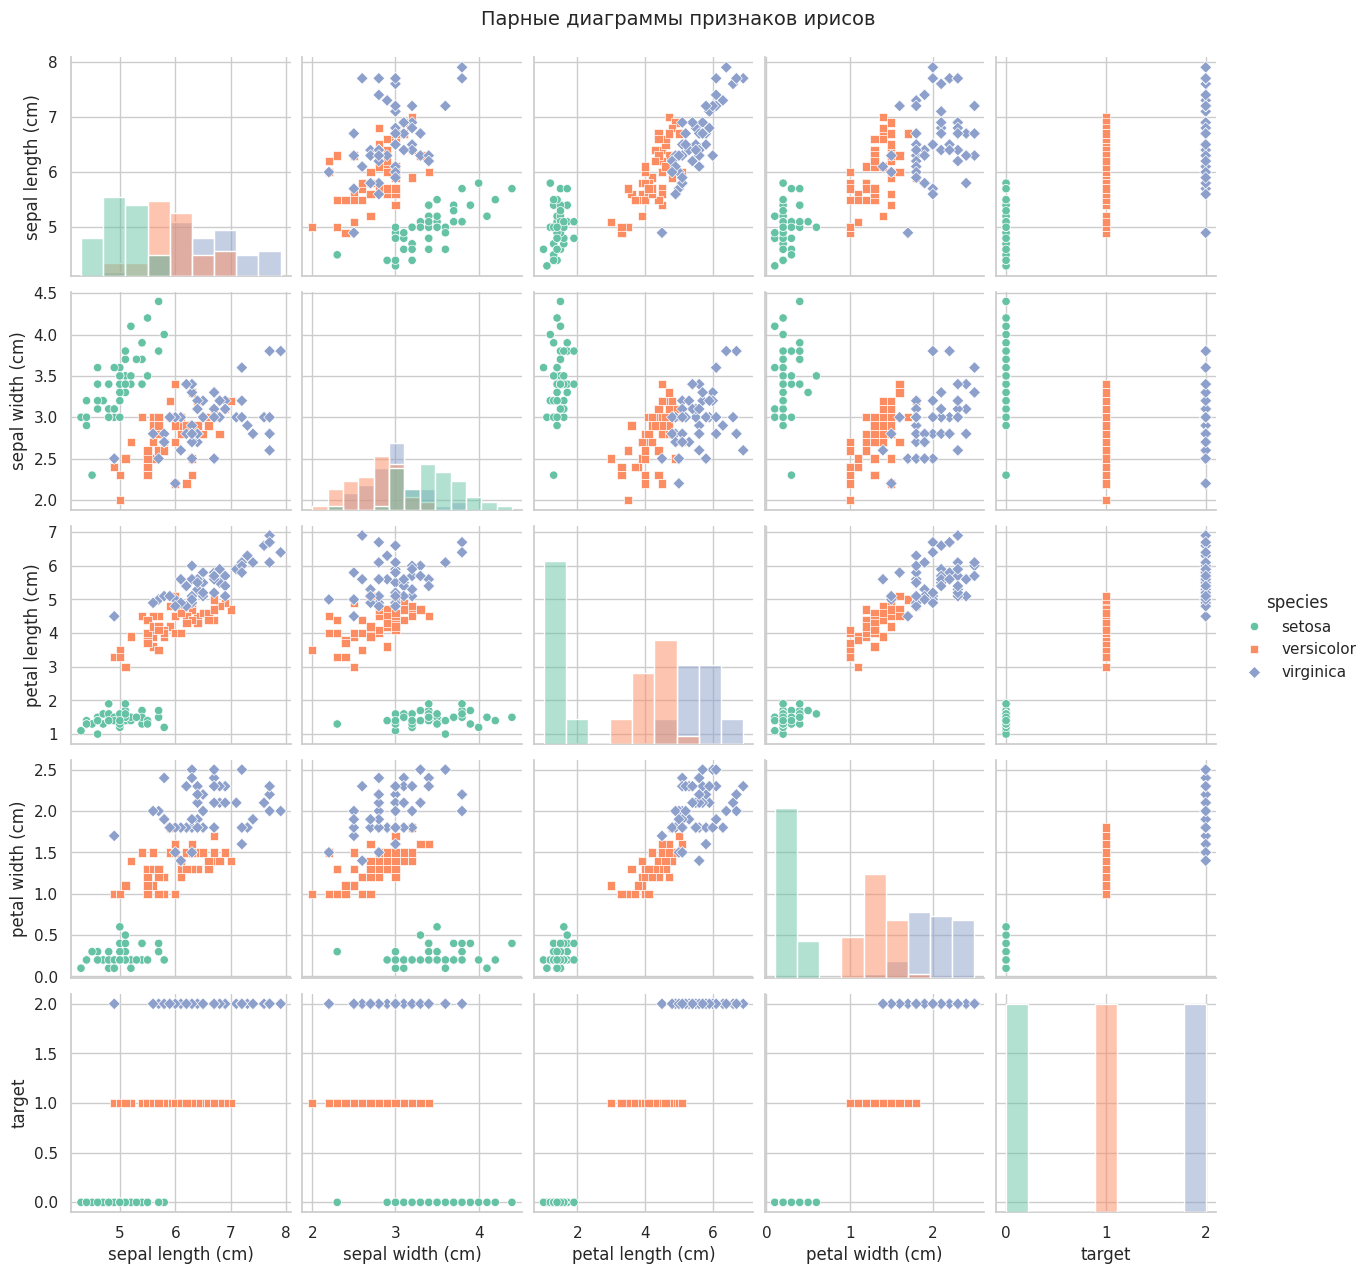

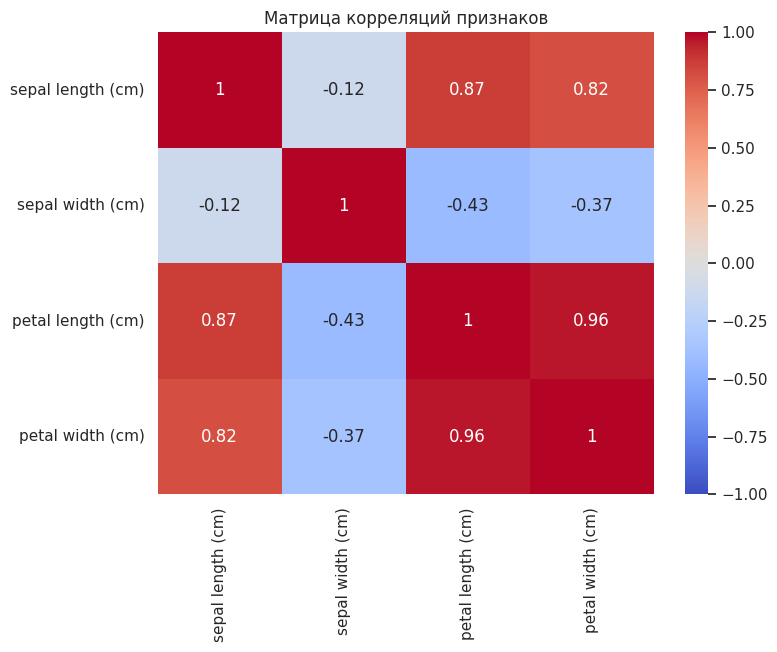

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set(style="whitegrid", palette="Set2")

# Парные диаграммы рассеяния с цветовым разделением по видам
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', diag_kind='hist', markers=['o', 's', 'D'])
plt.suptitle('Парные диаграммы признаков ирисов', y=1.02, fontsize=14)
plt.show()

# Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций признаков')
plt.show()


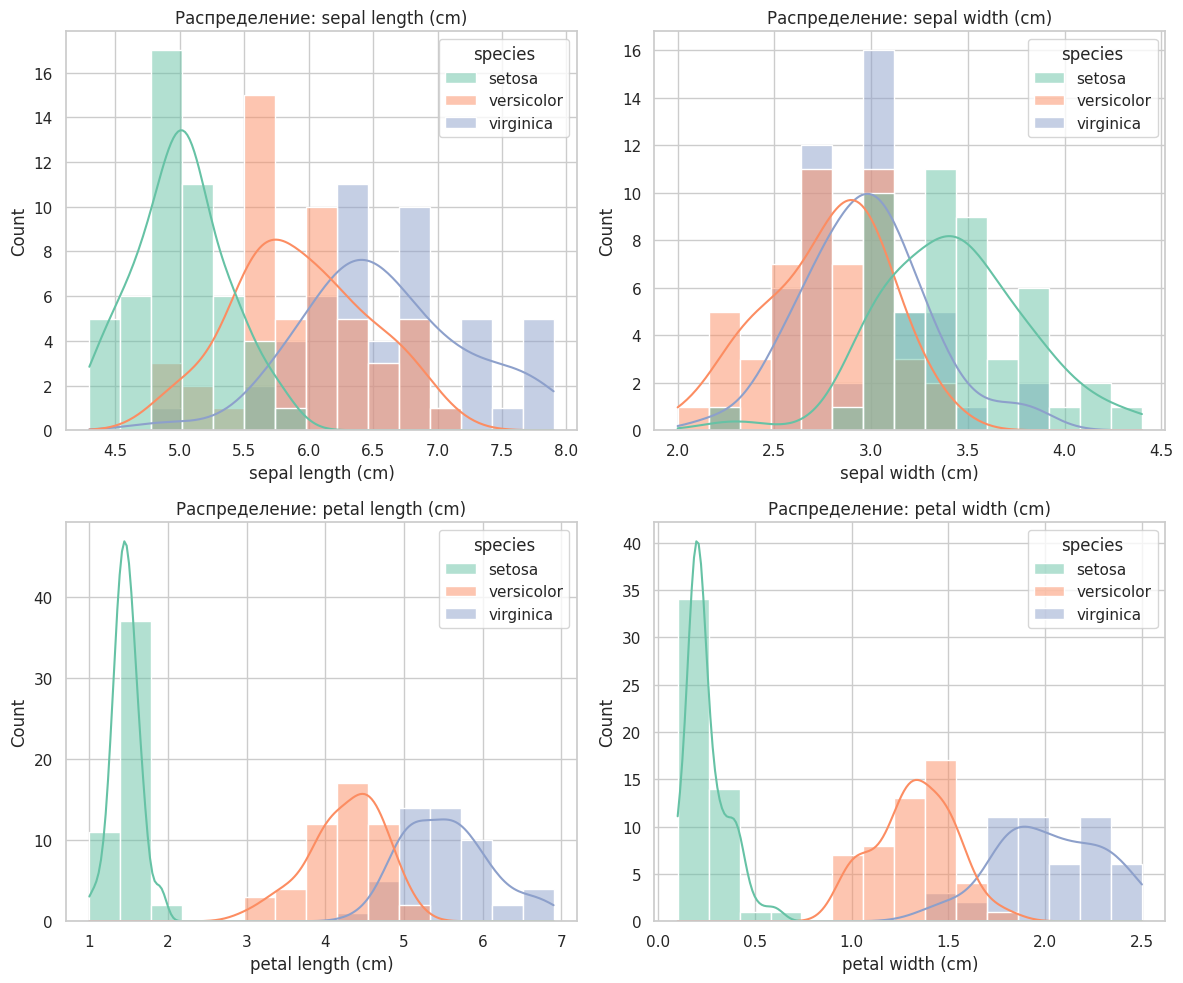

In [7]:
# Гистограммы всех признаков с наложением распределений по видам
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, col in enumerate(iris.feature_names):
    ax = axes[idx // 2, idx % 2]
    sns.histplot(data=df, x=col, hue='species', kde=True, ax=ax, bins=15)
    ax.set_title(f'Распределение: {col}')
plt.tight_layout()
plt.show()

In [11]:
# X — матрица признаков (все столбцы кроме целевых)
X = df.drop(['target', 'species'], axis=1).values
# y — вектор меток (можно использовать как числовые, так и строковые)
y = df['target'].values  # или df['species'].values для строковых меток

print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер вектора меток y: {y.shape}")

Размер матрицы признаков X: (150, 4)
Размер вектора меток y: (150,)


#Начало Практики 1.1

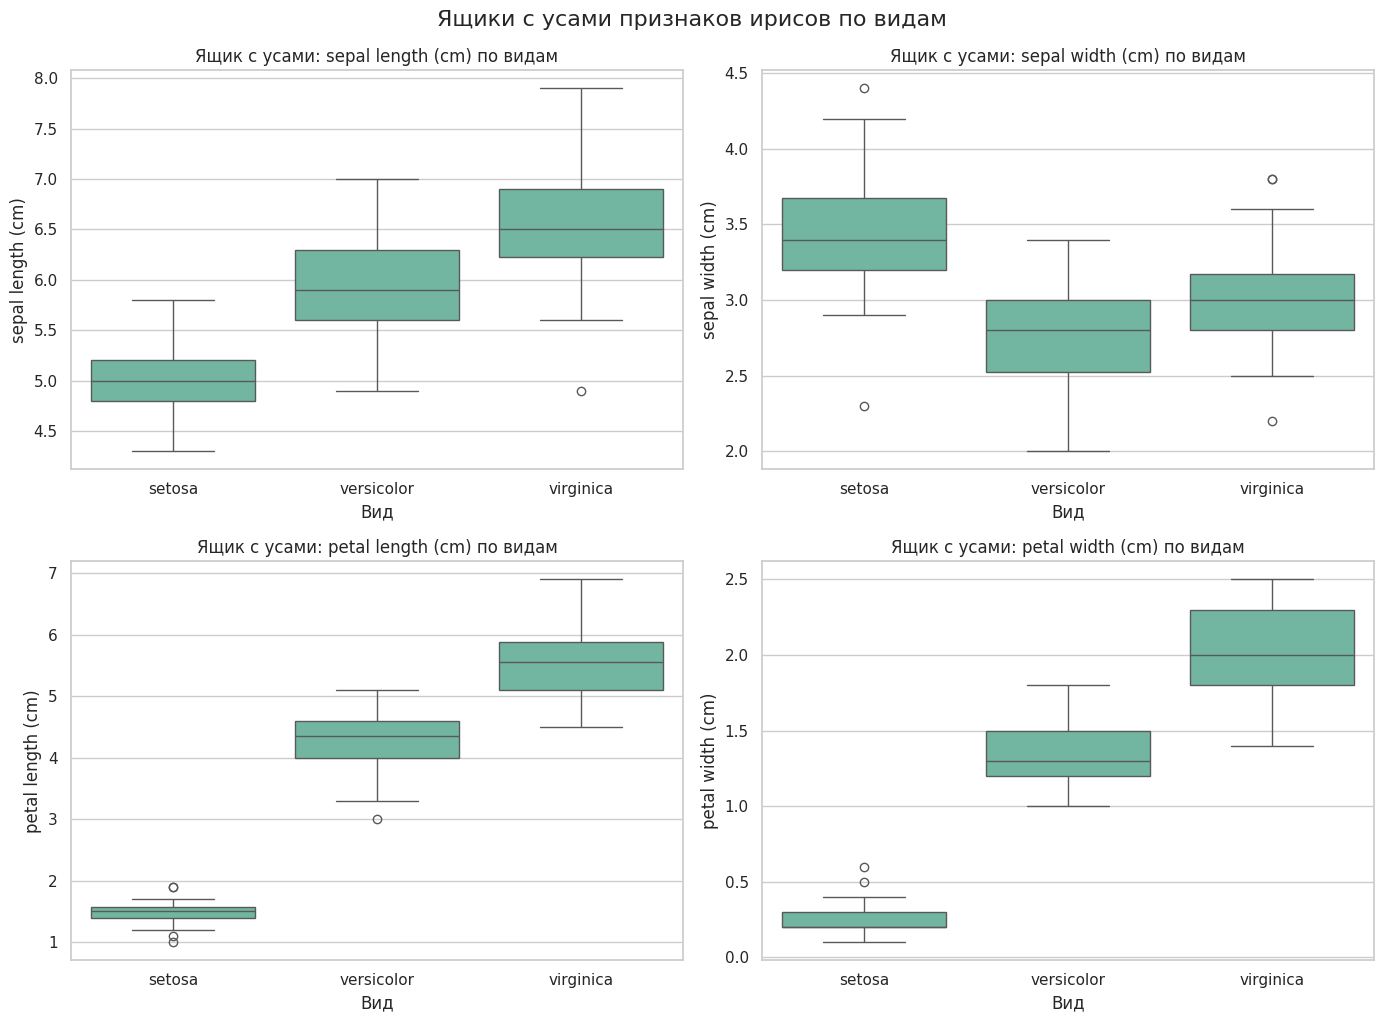


Анализ выбросов для Iris virginica по признаку 'sepal width (cm)':
Q1 (25-й перцентиль): 2.80
Q3 (75-й перцентиль): 3.18
Межквартильный размах (IQR): 0.38
Нижняя граница усов: 2.24
Верхняя граница усов: 3.74
Количество выбросов: 3
Общее количество наблюдений для Iris virginica: 50
Процент наблюдений, выходящих за границы усов: 6.00%
Значения выбросов: [3.8, 2.2, 3.8]


In [12]:
# Код был в основном взят с habr там подробный гайд по boxplot.
# Мне оставалось только адаптировать уже готовый код под мои нужды.
# Статью изучил
# https://habr.com/ru/articles/879840/

import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля графика
sns.set(style="whitegrid", palette="Set2")

# Создание ящиков с усами для каждого признака с разбивкой по видам
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Преобразование 2x2 массива осей в одномерный для удобства итерации

for i, col in enumerate(iris.feature_names):
    sns.boxplot(x='species', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Ящик с усами: {col} по видам')
    axes[i].set_xlabel('Вид')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Ящики с усами признаков ирисов по видам', y=1.02, fontsize=16)
plt.show()

# Анализ выбросов для Iris virginica по признаку 'sepal width'
# Получаем массив 'sepal width' для Iris virginica
virginica_sepal_width = df[df['species'] == 'virginica']['sepal width (cm)']

# Вычисляем IQR(Межквартильный Диапазон)
# quantile(): Это метод из библиотеки Pandas, который используется для
# вычисления квантилей (или перцентилей) данных.
# 0.25 (параметр): Этот параметр указывает, что мы хотим найти значение,
# которое делит данные таким образом, что 25% всех значений меньше или равно
# этому значению, а 75% значений больше этого. Другими словами, 0.25
# соответствует 25-му перцентилю, который и является первым квартилем (Q1).
# В контексте анализа выбросов, Q1 используется для вычисления межквартильного
# диапазона (IQR) и определения нижней границы для обнаружения выбросов (
# значения, которые значительно меньше Q1).
Q1 = virginica_sepal_width.quantile(0.25)
Q3 = virginica_sepal_width.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = virginica_sepal_width[(virginica_sepal_width < lower_bound) | (virginica_sepal_width > upper_bound)]

num_outliers = len(outliers)
total_virginica = len(virginica_sepal_width)

percentage_outliers = (num_outliers / total_virginica) * 100 if total_virginica > 0 else 0

print(f"\nАнализ выбросов для Iris virginica по признаку 'sepal width (cm)':")
print(f"Q1 (25-й перцентиль): {Q1:.2f}")
print(f"Q3 (75-й перцентиль): {Q3:.2f}")
print(f"Межквартильный размах (IQR): {IQR:.2f}")
print(f"Нижняя граница усов: {lower_bound:.2f}")
print(f"Верхняя граница усов: {upper_bound:.2f}")
print(f"Количество выбросов: {num_outliers}")
print(f"Общее количество наблюдений для Iris virginica: {total_virginica}")
print(f"Процент наблюдений, выходящих за границы усов: {percentage_outliers:.2f}%")

if num_outliers > 0:
    print(f"Значения выбросов: {outliers.tolist()}")
else:
    print("Выбросов не обнаружено.")

In [15]:
import pandas as pd

# Выбираем только числовые признаки для расчета коэффициента вариации
features_df = df.drop(['target', 'species'], axis=1)

# Рассчитываем стандартное отклонение для каждого признака
std_dev = features_df.std()

# Рассчитываем среднее значение для каждого признака
mean_val = features_df.mean()

# Рассчитываем коэффициент вариации (CV) для каждого признака
# CV = (стандартное отклонение / среднее) * 100%
coefficient_of_variation = (std_dev / mean_val) * 100

print("Коэффициенты вариации для каждого признака (%):")
print(coefficient_of_variation)

# Определяем признак с наибольшим коэффициентом вариации
most_variable_feature = coefficient_of_variation.idxmax()
max_cv_value = coefficient_of_variation.max()

print(f"\nНаиболее изменчивый признак относительно своего среднего значения: \
'{most_variable_feature}' с коэффициентом вариации {max_cv_value:.2f}%")

print("Коэффициент вариации помогает понять относительную изменчивость признака. Признаки с высоким CV имеют большой разброс значений относительно своего среднего. Если такие признаки используются в моделях машинного обучения без нормализации, они могут доминировать над признаками с меньшей изменчивостью, даже если последние важны для предсказания. Нормализация (например, масштабирование к диапазону [0, 1] или стандартизация к нулевому среднему и единичной дисперсии) выравнивает масштабы всех признаков, предотвращая нежелательное влияние признаков с большой абсолютной изменчивостью. Это особенно важно для алгоритмов, чувствительных к масштабу, таких как метод опорных векторов (SVM), K-ближайших соседей (KNN), логистическая регрессия или нейронные сети, где расстояния между точками или веса признаков играют ключевую роль.")


Коэффициенты вариации для каждого признака (%):
sepal length (cm)    14.171126
sepal width (cm)     14.256420
petal length (cm)    46.974407
petal width (cm)     63.555114
dtype: float64

Наиболее изменчивый признак относительно своего среднего значения: 'petal width (cm)' с коэффициентом вариации 63.56%

Почему это важно для нормализации данных?
Коэффициент вариации помогает понять относительную изменчивость признака. Признаки с высоким CV имеют большой разброс значений относительно своего среднего. Если такие признаки используются в моделях машинного обучения без нормализации, они могут доминировать над признаками с меньшей изменчивостью, даже если последние важны для предсказания. Нормализация (например, масштабирование к диапазону [0, 1] или стандартизация к нулевому среднему и единичной дисперсии) выравнивает масштабы всех признаков, предотвращая нежелательное влияние признаков с большой абсолютной изменчивостью. Это особенно важно для алгоритмов, чувствительных к масштабу, таких 

# Почему это важно для нормализации данных?
Коэффициент вариации(CV) помогает понять относительную изменчивость признака. Признаки с высоким CV имеют большой разброс значений относительно своего среднего. Если такие признаки используются в моделях машинного обучения без нормализации, они могут доминировать над признаками с меньшей изменчивостью, даже если последние важны для предсказания. Нормализация (например, масштабирование к диапазону [0, 1] или стандартизация к нулевому среднему и единичной дисперсии) выравнивает масштабы всех признаков, предотвращая нежелательное влияние признаков с большой абсолютной изменчивостью. Это особенно важно для алгоритмов, чувствительных к масштабу, таких как метод опорных векторов (SVM), K-ближайших соседей (KNN), логистическая регрессия или нейронные сети, где расстояния между точками или веса признаков играют ключевую роль.

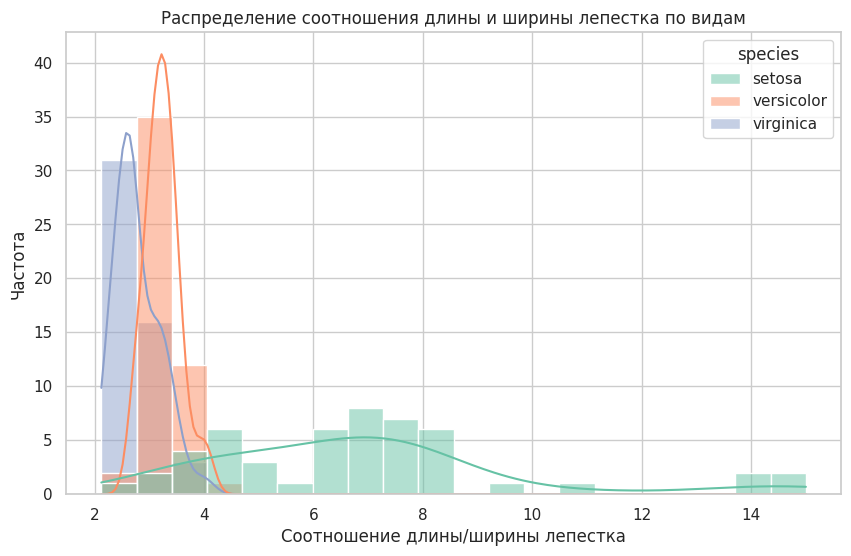

In [18]:
# Создание нового признака: соотношение длины и ширины лепестка
df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']

# Построение гистограммы для нового признака с разделением по видам
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='petal_ratio', hue='species', kde=True, bins=20)
plt.title('Распределение соотношения длины и ширины лепестка по видам')
plt.xlabel('Соотношение длины/ширины лепестка')
plt.ylabel('Частота')
plt.show()


# Анализ графика для новго признака «соотношение длины и ширины лепестка»
Гистограмма показывает, что новый признак 'petal_ratio' очень хорошо разделяет виды ирисов.
Iris setosa имеет значительно более высокие значения соотношения (лепестки длинные и узкие), чем Iris versicolor и Iris virginica.

Также наблюдается довольно хорошее разделение между Iris versicolor и Iris virginica, хотя и с некоторым перекрытием.

По сравнению с исходными признаками, 'petal_ratio' демонстрирует более четкое разделение классов, особенно для Iris setosa, что делает его потенциально очень полезным для задач классификации.

# Выводы по датасету Iris
Датасет Iris демонстрирует четкое разделение видов на основе признаков лепестков и чашелистиков, особенно хорошо отделяя Iris setosa. Признаки лепестков (`petal length`, `petal width`) показывают более высокую изменчивость и корреляцию, а также лучше подходят для классификации, чем признаки чашелистиков. Создание производных признаков, таких как соотношение длины и ширины лепестка, может значительно улучшить разделимость классов.